In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import itertools
import time

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split  # ---- (line 97)

In [2]:
# ----- Add device setup at the top -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ----- Define LSTM Experimental Grids -----
"""
hidden_sizes = [32, 64, 128]
num_layers = [1, 2]
dropouts = [0.0, 0.3, 0.5]
bidirectional_options = [False, True]

seq_lengths = [8, 12, 16]
pred_lengths = [8, 12]

batch_sizes = [32, 64, 128]
learning_rates = [0.0005, 0.001, 0.005]
optimizers = {
    "adam": optim.Adam,
    "rmsprop": optim.RMSprop,
    "sgd": optim.SGD
}
epochs_list = [10, 20]
gradient_clipping_values = [None, 1.0, 5.0]
"""
hidden_sizes = [100]  
num_layers = [4] 
dropouts = [0.2]
bidirectional_options = [False]
 
seq_lengths = [15] 
pred_lengths = [15] 
 
batch_sizes = [32, 64] 
learning_rates = [0.0005, 0.005] 
optimizers = {
    "adam": optim.Adam,
}
epochs_list = [5,10] 
gradient_clipping_values = [None]


In [4]:
# ----- Load and Preprocess Data -----
df = pd.read_csv("converted_zara_1.csv")
x_mean, x_std = df['x'].mean(), df['x'].std()
y_mean, y_std = df['y'].mean(), df['y'].std()
df['x'] = (df['x'] - x_mean) / x_std
df['y'] = (df['y'] - y_mean) / y_std


In [5]:
# ----- Dataset Definition -----
class TrajectoryDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        obs, fut = self.data[idx]
        return torch.tensor(obs, dtype=torch.float32), torch.tensor(fut, dtype=torch.float32)

In [6]:
# ----- LSTM Model -----
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_len, num_layers, dropout, bidirectional):
        super(LSTMModel, self).__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional
        )
        direction_multiplier = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * direction_multiplier, 2 * output_len)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        hn = torch.cat((hn[-2], hn[-1]), dim=1) if self.bidirectional else hn[-1]
        out = self.fc(hn)
        return out.view(-1, self.fc.out_features // 2, 2)  #----!


In [7]:
# ----- Training Grid Search Loop -----
results = []  #----!
experiment_id = 0

for hs, nl, do, bi, sl, pl, bs, lr, opt_name, ep, gc in itertools.product(
        hidden_sizes, num_layers, dropouts, bidirectional_options,
        seq_lengths, pred_lengths, batch_sizes, learning_rates,
        optimizers.keys(), epochs_list, gradient_clipping_values):

    PRED_LEN = pl
    SEQ_LEN = sl

    start_time = time.time()

    # Rebuild trajectories per configuration
    trajectories = []
    for pid, person_df in df.groupby("person_id"):
        person_df = person_df.sort_values("frame_id")
        coords = person_df[['x', 'y']].values
        for i in range(len(coords) - SEQ_LEN - PRED_LEN):
            obs = coords[i:i+SEQ_LEN]
            pred = coords[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN]
            trajectories.append((obs, pred))

    train_data, test_data = train_test_split(trajectories, test_size=0.2, random_state=42)
    train_loader = DataLoader(TrajectoryDataset(train_data), batch_size=bs, shuffle=True)
    test_loader = DataLoader(TrajectoryDataset(test_data), batch_size=bs, shuffle=False)

    #model = LSTMModel(input_size=2, hidden_size=hs, output_len=pl, num_layers=nl, dropout=do, bidirectional=bi)
    model = LSTMModel(input_size=2, hidden_size=hs, output_len=pl, num_layers=nl, dropout=do, bidirectional=bi).to(device)
    criterion = nn.MSELoss()
    optimizer = optimizers[opt_name](model.parameters(), lr=lr)

    print(f"\n--- Experiment {experiment_id}: HS={hs}, NL={nl}, DO={do}, BI={bi}, SL={sl}, PL={pl}, BS={bs}, LR={lr}, OPT={opt_name}, EP={ep}, GC={gc} ---")

    for epoch in range(ep):
        train_loss = 0
        model.train()
        for obs, fut in train_loader:  #----!
            obs = obs.to(device)  #-------
            fut = fut.to(device)  #-------
            pred = model(obs)
            loss = criterion(pred, fut)
            optimizer.zero_grad()
            loss.backward()
            if gc is not None:
                nn.utils.clip_grad_norm_(model.parameters(), gc)
            optimizer.step()
            train_loss += loss.item()

        print(f"Epoch {epoch+1}/{ep}, Train Loss: {train_loss/len(train_loader):.4f}")

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for obs, fut in test_loader:
            obs = obs.to(device)  #-------
            fut = fut.to(device)  #-------
            pred = model(obs)
            loss = criterion(pred, fut)
            test_loss += loss.item()
    test_loss /= len(test_loader)

    duration = time.time() - start_time
    print(f"Experiment {experiment_id} completed in {duration:.2f} seconds")

    torch.save(model.state_dict(), f"lstm_zara_exp_{experiment_id}.pth")
    results.append({
        "experiment_id": experiment_id,
        "hidden_size": hs,
        "num_layers": nl,
        "dropout": do,
        "bidirectional": bi,
        "seq_len": sl,
        "pred_len": pl,
        "batch_size": bs,
        "learning_rate": lr,
        "optimizer": opt_name,
        "epochs": ep,
        "grad_clip": gc,
        "train_loss": train_loss / len(train_loader),
        "test_loss": test_loss,
        "training_time_sec": duration
    })

    experiment_id += 1

    



--- Experiment 0: HS=100, NL=4, DO=0.2, BI=False, SL=15, PL=15, BS=32, LR=0.0005, OPT=adam, EP=5, GC=None ---
Epoch 1/5, Train Loss: 0.0569
Epoch 2/5, Train Loss: 0.0098
Epoch 3/5, Train Loss: 0.0064
Epoch 4/5, Train Loss: 0.0051
Epoch 5/5, Train Loss: 0.0045
Experiment 0 completed in 18.05 seconds

--- Experiment 1: HS=100, NL=4, DO=0.2, BI=False, SL=15, PL=15, BS=32, LR=0.0005, OPT=adam, EP=10, GC=None ---
Epoch 1/10, Train Loss: 0.0534
Epoch 2/10, Train Loss: 0.0111
Epoch 3/10, Train Loss: 0.0067
Epoch 4/10, Train Loss: 0.0054
Epoch 5/10, Train Loss: 0.0048
Epoch 6/10, Train Loss: 0.0039
Epoch 7/10, Train Loss: 0.0032
Epoch 8/10, Train Loss: 0.0029
Epoch 9/10, Train Loss: 0.0026
Epoch 10/10, Train Loss: 0.0024
Experiment 1 completed in 36.43 seconds

--- Experiment 2: HS=100, NL=4, DO=0.2, BI=False, SL=15, PL=15, BS=32, LR=0.005, OPT=adam, EP=5, GC=None ---
Epoch 1/5, Train Loss: 0.0308
Epoch 2/5, Train Loss: 0.0116
Epoch 3/5, Train Loss: 0.0086
Epoch 4/5, Train Loss: 0.0070
Epoch 

In [8]:
results_df = pd.DataFrame(results)
print(results_df.sort_values("test_loss"))  #----!
results_df.to_json("results_metadata.json", orient="records", indent=2)

   experiment_id  hidden_size  num_layers  dropout  bidirectional  seq_len  \
5              5          100           4      0.2          False       15   
1              1          100           4      0.2          False       15   
3              3          100           4      0.2          False       15   
4              4          100           4      0.2          False       15   
6              6          100           4      0.2          False       15   
7              7          100           4      0.2          False       15   
2              2          100           4      0.2          False       15   
0              0          100           4      0.2          False       15   

   pred_len  batch_size  learning_rate optimizer  epochs grad_clip  \
5        15          64         0.0005      adam      10      None   
1        15          32         0.0005      adam      10      None   
3        15          32         0.0050      adam      10      None   
4        15      

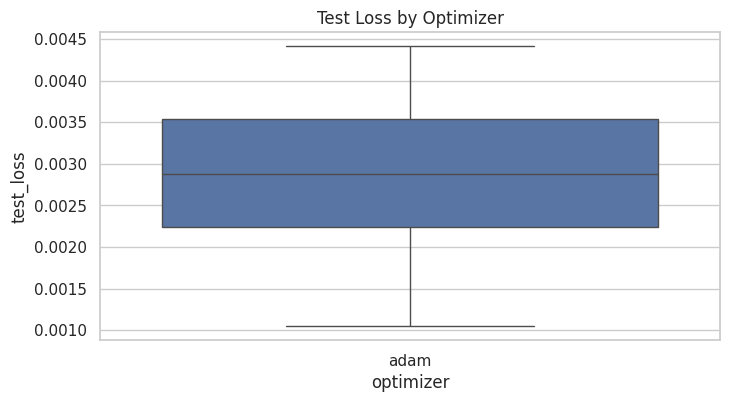

/tmp/ipykernel_828287/2809003659.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=results_df, x="dropout", y="test_loss", ci="sd")  #----!


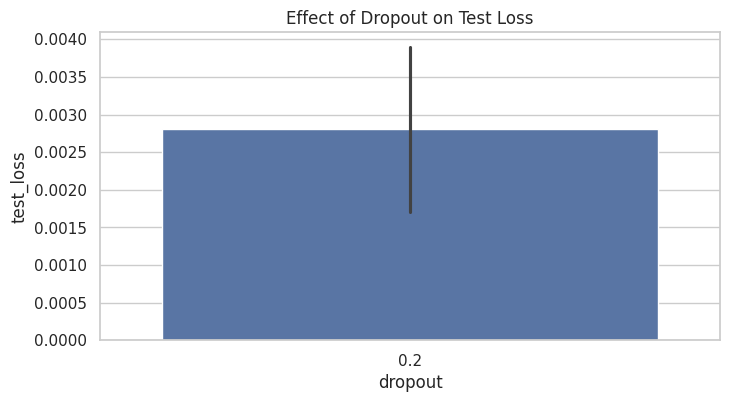

/tmp/ipykernel_828287/2809003659.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=results_df, x="hidden_size", y="test_loss", ci="sd")  #----!


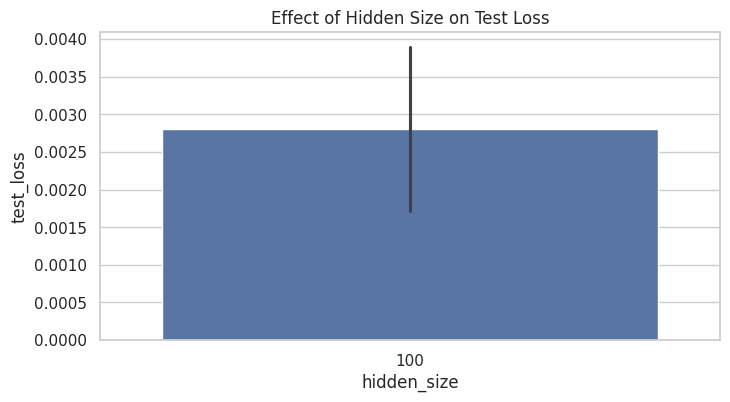

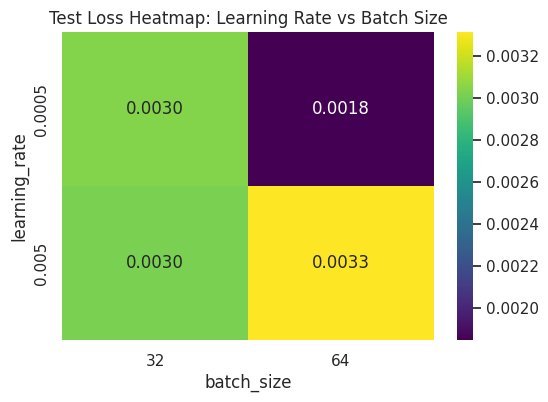

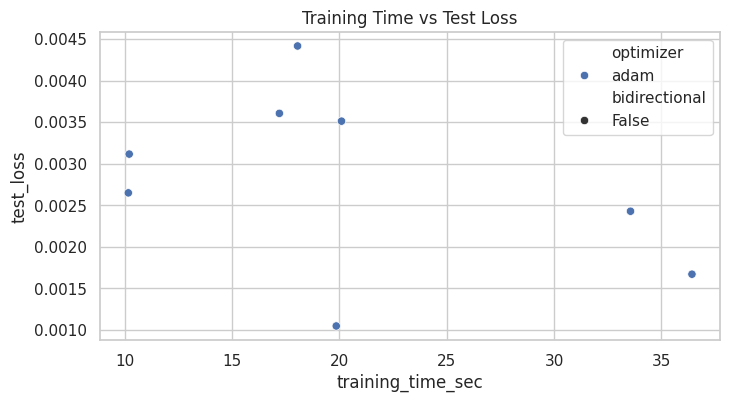

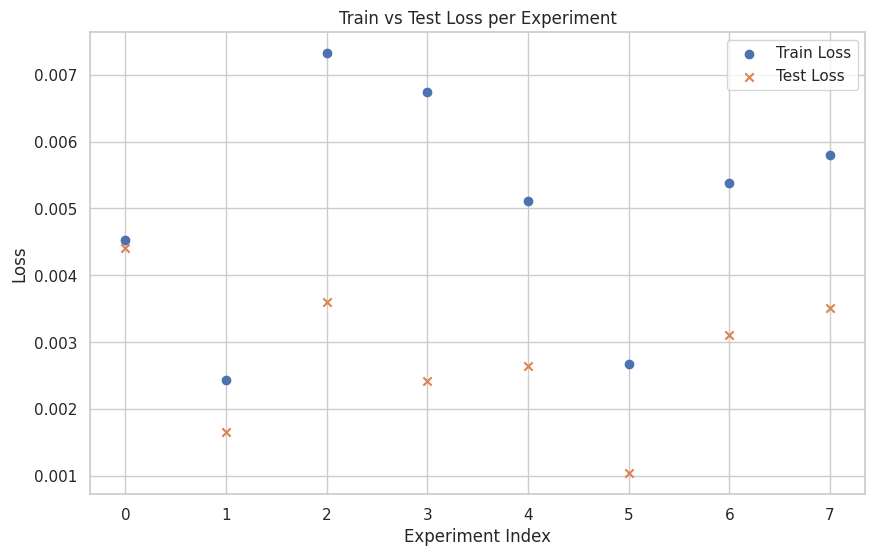

In [9]:
# ---- Visualizations ---- #----!
sns.set(style="whitegrid")  #----!

# Boxplot: Loss by Optimizer
plt.figure(figsize=(8, 4))
sns.boxplot(data=results_df, x="optimizer", y="test_loss")  #----!
plt.title("Test Loss by Optimizer")  #----!
plt.show()

# Barplot: Loss by Dropout
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="dropout", y="test_loss", ci="sd")  #----!
plt.title("Effect of Dropout on Test Loss")  #----!
plt.show()

# Barplot: Loss by Hidden Size
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="hidden_size", y="test_loss", ci="sd")  #----!
plt.title("Effect of Hidden Size on Test Loss")  #----!
plt.show()

# Heatmap: Learning Rate vs Batch Size
pivot = results_df.pivot_table(index="learning_rate", columns="batch_size", values="test_loss", aggfunc='mean')  #----!
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis")  #----!
plt.title("Test Loss Heatmap: Learning Rate vs Batch Size")  #----!
plt.show()

# Scatterplot: Training Time vs Loss (colored by optimizer)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=results_df, x="training_time_sec", y="test_loss", hue="optimizer", style="bidirectional")  #----!
plt.title("Training Time vs Test Loss")  #----!
plt.show()

# Additional: Train vs Test Loss Comparison
plt.figure(figsize=(10, 6))  #----!
plt.scatter(results_df.index, results_df["train_loss"], label="Train Loss", marker="o")  #----!
plt.scatter(results_df.index, results_df["test_loss"], label="Test Loss", marker="x")  #----!
plt.xlabel("Experiment Index")  #----!
plt.ylabel("Loss")  #----!
plt.title("Train vs Test Loss per Experiment")  #----!
plt.legend()  #----!
plt.grid(True)  #----!
plt.show()  #----!


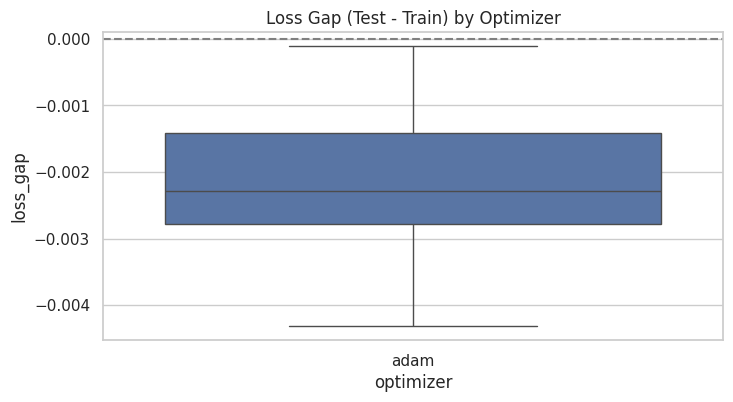

/tmp/ipykernel_828287/2252072576.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=results_df, x="dropout", y="loss_gap", ci="sd")  #----!


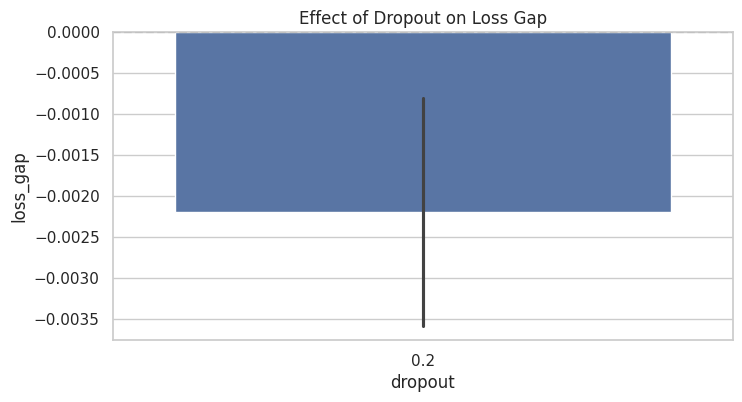

In [10]:

# Additional: Loss Gap (Overfitting Indicator) by Optimizer  #----!
results_df['loss_gap'] = results_df['test_loss'] - results_df['train_loss']  #----!
plt.figure(figsize=(8, 4))  #----!
sns.boxplot(data=results_df, x="optimizer", y="loss_gap")  #----!
plt.title("Loss Gap (Test - Train) by Optimizer")  #----!
plt.axhline(0, color='gray', linestyle='--')  #----!
plt.show()  #----!

# Additional: Loss Gap by Dropout  #----!
plt.figure(figsize=(8, 4))  #----!
sns.barplot(data=results_df, x="dropout", y="loss_gap", ci="sd")  #----!
plt.title("Effect of Dropout on Loss Gap")  #----!
plt.axhline(0, color='gray', linestyle='--')  #----!
plt.show()  #----!
